## Computing Residual and Data Exploration

In [4]:
# %% Import the libraries we need
import matplotlib.pyplot as plt
import pandas as pd

# -------------------------------
# 1. Load the dataset from parquet
# -------------------------------
# Make sure this path matches your local file location
dataset = pd.read_parquet("./renewables-dataset.parquet")

# %% Ensure the time column is parsed as datetime
dataset["Time"] = pd.to_datetime(dataset["Time"])

# Inspect the first rows
print(dataset.head())

                       Time ID  demand_MWh  supply_MWh  solar_MWh   wind_MWh  \
0 2012-01-01 00:00:00+00:00  1     75.6549    9.150821        0.0  18.301642   
1 2012-01-01 00:00:00+00:00  2    557.8868    6.196411        0.0  12.392822   
2 2012-01-01 00:00:00+00:00  3     15.5237    6.855084        0.0  13.710167   
3 2012-01-01 00:00:00+00:00  4      8.6425    7.824092        0.0  15.648183   
4 2012-01-01 00:00:00+00:00  5     85.3649    2.053690        0.0   4.107380   

   solar_rel_prod  wind_rel_prod   latitude  longitude country  \
0             0.0         0.0284  42.094674  -8.113982     POR   
1             0.0         0.0103  41.587435  -8.326462     POR   
2             0.0         0.0283  41.585994  -6.722728     POR   
3             0.0         0.0408  41.597684  -6.342848     POR   
4             0.0         0.0092  41.373957  -7.350949     POR   

   solar_layout_MW  wind_layout_MW  
0         982.8607        644.4240  
1        1361.0601       1203.1866  
2         7

In [5]:
dataset.columns

Index(['Time', 'ID', 'demand_MWh', 'supply_MWh', 'solar_MWh', 'wind_MWh',
       'solar_rel_prod', 'wind_rel_prod', 'latitude', 'longitude', 'country',
       'solar_layout_MW', 'wind_layout_MW'],
      dtype='str')

In [6]:
dataset.nunique()

Time                  26304
ID                     1494
demand_MWh          5510473
supply_MWh         23869972
solar_MWh          11162003
wind_MWh            7646988
solar_rel_prod        15977
wind_rel_prod         10001
latitude               1494
longitude              1494
country                  25
solar_layout_MW        1491
wind_layout_MW         1492
dtype: int64

In [7]:
dataset.describe()

,demand_MWh,supply_MWh,solar_MWh,wind_MWh,solar_rel_prod,wind_rel_prod,latitude,longitude,solar_layout_MW,wind_layout_MW
count,3.929818e+07,3.929818e+07,3.929818e+07,3.929818e+07,3.929818e+07,3.929818e+07,3.929818e+07,3.929818e+07,3.929818e+07,3.929818e+07
mean,1.857547e+02,1.856991e+02,1.856436e+02,1.857547e+02,2.594883e-01,1.437274e-01,4.644724e+01,9.653972e+00,6.909662e+02,8.082173e+02
std,2.819363e+02,5.639259e+02,4.316870e+02,1.036305e+03,3.855802e-01,1.938839e-01,4.125963e+00,9.112521e+00,6.603952e+02,1.846573e+03
min,0.000000e+00,4.508800e-04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.557556e+01,-9.243608e+00,3.017560e+01,8.600200e+00
25%,5.409840e+01,1.129004e+01,0.000000e+00,5.664576e+00,0.000000e+00,1.770000e-02,4.340947e+01,2.899177e+00,3.018575e+02,2.355503e+02
50%,1.159686e+02,6.048662e+01,0.000000e+00,2.951699e+01,0.000000e+00,6.200000e-02,4.642589e+01,8.988349e+00,5.166395e+02,4.725908e+02
75%,2.184617e+02,1.946903e+02,2.016292e+02,1.174484e+02,5.050000e-01,1.855000e-01,4.964264e+01,1.722765e+01,8.588355e+02,8.374009e+02
max,9.930241e+03,2.037558e+04,1.470165e+04,4.072136e+04,1.679500e+00,1.000000e+00,5.724720e+01,2.896797e+01,1.075547e+04,4.072543e+04


- 1,494 buses connected by 2,156 AC lines + 1 HVDC link; voltage levels 110–380 kV
- Covers mainland Europe, excluding British Isles, Fennoscandia and Baltic states
- 3 years of hourly bus-level signals (2012–2014) from two independent
meteorological sources: built-in sensitivity check.

In [82]:
# ----------------------------------------------
# 2. Choose penetration/scaling for solar + wind
# ----------------------------------------------
# These scale the already-computed solar_MWh and wind_MWh columns
a_s = 0.01  # solar matches (a_s x 100)% of the average yearly demand across EU
a_w = 0.05  # wind matches (a_w x 100)% of the average yearly demand across EU


# Compute scaled supply and residual load
dataset_residual = dataset.assign(
    solar_scaled_MWh=lambda df: a_s * df["solar_MWh"],
    wind_scaled_MWh=lambda df: a_w * df["wind_MWh"],
    supply_scaled_MWh=lambda df: df["solar_scaled_MWh"] + df["wind_scaled_MWh"],
    residual_MWh=lambda df: df["demand_MWh"] - df["supply_scaled_MWh"],
)[
    [
        "Time",
        "ID",
        'latitude', 
        'longitude', 
        'country',
        "solar_scaled_MWh",
        "wind_scaled_MWh",
        "demand_MWh",
        "supply_scaled_MWh",
        "residual_MWh",
    ]
]

# Optional: inspect the result
dataset_residual.head()

,Time,ID,latitude,longitude,country,solar_scaled_MWh,wind_scaled_MWh,demand_MWh,supply_scaled_MWh,residual_MWh
0,2012-01-01 00:00:00+00:00,1,42.094674,-8.113982,POR,0.0,0.915082,75.6549,0.915082,74.739818
1,2012-01-01 00:00:00+00:00,2,41.587435,-8.326462,POR,0.0,0.619641,557.8868,0.619641,557.267159
2,2012-01-01 00:00:00+00:00,3,41.585994,-6.722728,POR,0.0,0.685508,15.5237,0.685508,14.838192
3,2012-01-01 00:00:00+00:00,4,41.597684,-6.342848,POR,0.0,0.782409,8.6425,0.782409,7.860091
4,2012-01-01 00:00:00+00:00,5,41.373957,-7.350949,POR,0.0,0.205369,85.3649,0.205369,85.159531


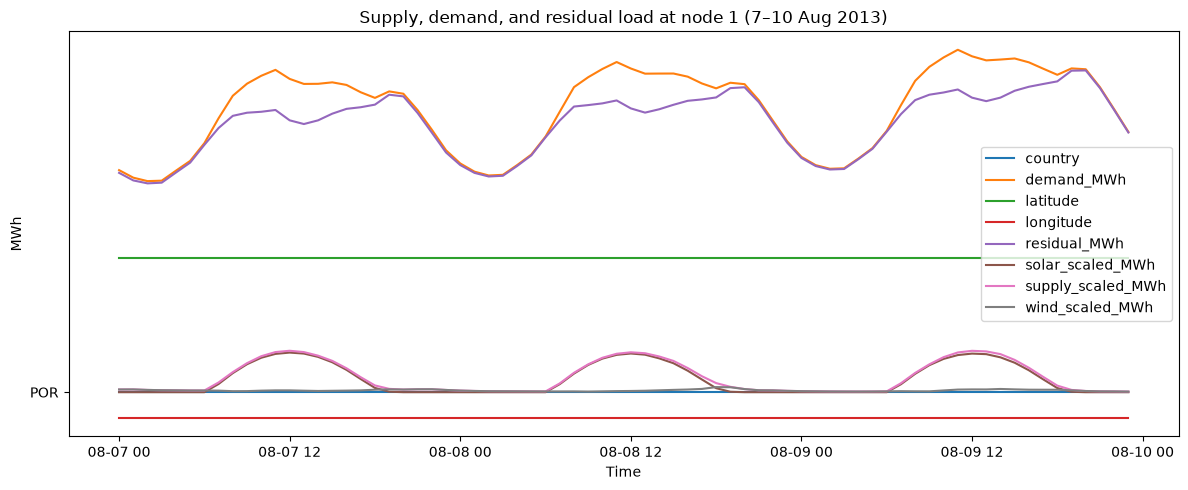

In [9]:
# %% ---------------------------------------------------------
# 3. Filter to one node and to the dates 7-10 August 2013
# ---------------------------------------------------------
# Important: ID is stored as a string
subset_station = dataset_residual.loc[dataset_residual["ID"] == "1"].drop(columns="ID")

# %%
mask = (
    (subset_station["Time"].dt.year ==2012)
    & (subset_station["Time"].dt.month == 8)
     & (subset_station["Time"].dt.day.isin([7,8,9]))
)

subset_data = subset_station.loc[mask].melt(
    id_vars="Time",
    var_name="source",
    value_name="MWh",
)

plt.figure(figsize=(12, 5))


# plotting: 
for source, group in subset_data.groupby("source"):
    plt.plot(group["Time"], group["MWh"], label=source)

plt.xlabel("Time")
plt.ylabel("MWh")
plt.title("Supply, demand, and residual load at node 1 (7–10 Aug 2013)")
plt.legend()
plt.tight_layout()
plt.show()


## Monthly long-term spatial pattern plotted

In [10]:
# Ensure datetime
dataset_residual["Time"] = pd.to_datetime(dataset_residual["Time"])

monthly = (
    dataset_residual
    .groupby([
        pd.Grouper(key="Time", freq="MS"),  # Month Start
        "ID"
    ])
    .agg(
        demand_MWh=("demand_MWh", "mean"),
        supply_MWh=("supply_scaled_MWh", "mean"),
        solar_MWh=("solar_scaled_MWh", "mean"),
        wind_MWh=("wind_scaled_MWh", "mean"),
        residual_MWh=("residual_MWh", "median"),
        latitude=("latitude", "first"),
        longitude=("longitude", "first"),
        country=("country", "first"),
    )
    .reset_index()
)

daily = (
    dataset_residual
    .groupby([
        pd.Grouper(key="Time", freq="D"),  # Daily
        "ID"
    ])
    .agg(
        demand_MWh=("demand_MWh", "mean"),
        supply_MWh=("supply_scaled_MWh", "mean"),
        solar_MWh=("solar_scaled_MWh", "mean"),
        wind_MWh=("wind_scaled_MWh", "mean"),
        residual_MWh=("residual_MWh", "median"),
        latitude=("latitude", "first"),
        longitude=("longitude", "first"),
        country=("country", "first"),
    )
    .reset_index()
)

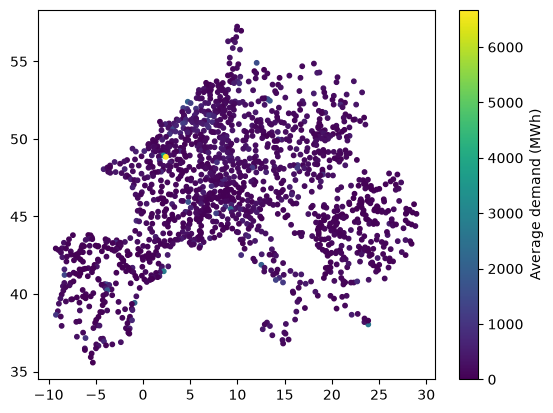

In [11]:
# plotting the monthly graph
jan2012 = monthly[monthly["Time"] == "2012-01-01"]
plt.scatter(
    jan2012["longitude"],
    jan2012["latitude"],
    c=jan2012["demand_MWh"],
    s=10,
    cmap="viridis"
)
plt.colorbar(label="Average demand (MWh)")

In [12]:
# pip install cartopy pillow if needed
import matplotlib.animation as animation
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [13]:
monthly = monthly.sort_values("Time")

# --------------------------------------------------
# 1. Choose variable to animate
# --------------------------------------------------

var = "residual_MWh"      # change to "supply_MWh", "solar_MWh", "wind_MWh"
title_var = "Median Residual"
unit = "MWh"

vmin = monthly[var].quantile(0.05)
vmax = monthly[var].quantile(0.95)

times = monthly["Time"].sort_values().unique()

In [14]:
negative_res = monthly[monthly["residual_MWh"]<0]
negative_res.describe()

,demand_MWh,supply_MWh,solar_MWh,wind_MWh,residual_MWh,latitude,longitude
count,744.000000,744.000000,744.000000,744.000000,744.000000,744.000000,744.000000
mean,60.303990,185.570336,0.720048,184.850288,-122.597179,49.028985,6.711190
std,94.893701,300.140500,1.015783,299.841286,273.582654,6.757559,8.541850
min,0.000000,0.202908,0.033940,0.066500,-1815.992929,35.575558,-9.243608
25%,0.000000,5.536811,0.145714,5.328768,-87.887204,43.786176,0.655201
50%,20.324794,72.803545,0.281781,72.455463,-20.534128,53.157787,8.874525
75%,76.728883,188.305254,0.803720,187.920403,-2.444989,54.374364,11.797743
max,362.444701,1570.854116,6.128843,1570.795563,-0.000329,57.247204,28.967975


In [15]:
negative_res.head(20)
negative_res.tail(20)

,Time,ID,demand_MWh,supply_MWh,solar_MWh,wind_MWh,residual_MWh,latitude,longitude,country
52562,2014-12-01 00:00:00+00:00,1251,0.000000,1.969187,0.159121,1.810066,-1.039033,35.575558,-5.314844,ESP
52561,2014-12-01 00:00:00+00:00,1250,0.000000,51.208331,0.034601,51.173730,-57.435756,51.111581,1.792708,FRA
52621,2014-12-01 00:00:00+00:00,131,9.577490,21.673745,1.756799,19.916946,-11.631322,41.165520,-0.818855,ESP
52654,2014-12-01 00:00:00+00:00,134,2.421783,2.797121,0.135542,2.661579,-0.926636,40.968337,0.948892,ESP
52649,2014-12-01 00:00:00+00:00,1335,0.000000,12.217211,0.051191,12.166021,-11.523378,43.236793,28.449488,BGR
52335,2014-12-01 00:00:00+00:00,1039,281.037813,357.032113,0.783617,356.248497,-104.785638,55.244576,9.196373,DNK
52376,2014-12-01 00:00:00+00:00,1076,138.704302,179.493398,0.533353,178.960045,-38.913465,54.687465,16.865434,POL
52331,2014-12-01 00:00:00+00:00,1035,301.957318,1065.490058,1.001597,1064.488461,-933.616433,56.300164,9.007699,DNK
52387,2014-12-01 00:00:00+00:00,1086,59.685457,155.315823,0.321489,154.994334,-94.642589,53.943026,14.467937,POL
52403,2014-12-01 00:00:00+00:00,110,7.530098,9.343631,1.450970,7.892661,-0.148108,41.695121,-2.178489,ESP


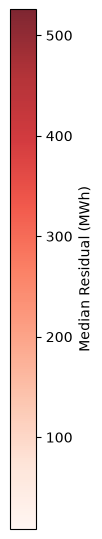

In [16]:
# --------------------------------------------------
# 2. Key European cities
# --------------------------------------------------

cities = {
    "London": (-0.1276, 51.5074),
    "Paris": (2.3522, 48.8566),
    "Berlin": (13.4050, 52.5200),
    "Madrid": (-3.7038, 40.4168),
    "Rome": (12.4964, 41.9028),
    "Vienna": (16.3738, 48.2082),
    "Warsaw": (21.0122, 52.2297),
    "Amsterdam": (4.9041, 52.3676),
    "Prague": (14.4378, 50.0755),
    "Athens": (23.7275, 37.9838),
    "Stockholm": (18.0686, 59.3293),
}

# Europe map extent: [lon_min, lon_max, lat_min, lat_max]
extent = [-25, 45, 34, 72]

# --------------------------------------------------
# 3. Create base figure
# --------------------------------------------------

fig = plt.figure(figsize=(13, 9))
ax = plt.axes(projection=ccrs.PlateCarree())

def draw_base_map():
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor="#f2f2f2")
    ax.add_feature(cfeature.OCEAN, facecolor="#dbeeff")
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linestyle=":", linewidth=0.6)
    ax.add_feature(cfeature.LAKES, facecolor="#dbeeff", edgecolor="none")
    ax.add_feature(cfeature.RIVERS, linewidth=0.3)

    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.3,
        color="gray",
        alpha=0.5,
        linestyle="--"
    )
    gl.top_labels = False
    gl.right_labels = False

    for name, (lon, lat) in cities.items():
        ax.plot(
            lon, lat,
            marker="*",
            color="black",
            markersize=7,
            transform=ccrs.PlateCarree(),
            zorder=5
        )
        ax.text(
            lon + 0.5,
            lat + 0.4,
            name,
            fontsize=8,
            transform=ccrs.PlateCarree(),
            zorder=5
        )
        
# --------------------------------------------------
# 4. First frame and colour bar
# --------------------------------------------------

first_month = monthly[monthly["Time"] == times[0]]

draw_base_map()

scatter = ax.scatter(
    first_month["longitude"],
    first_month["latitude"],
    c=first_month[var],
    s=12,
    cmap="Reds",
    vmin=vmin,
    vmax=vmax,
    alpha=0.85,
    edgecolor="white",
    linewidth=0.2,
    transform=ccrs.PlateCarree()
)

cbar = plt.colorbar(scatter, ax=ax, shrink=0.75, pad=0.03)
cbar.set_label(f"{title_var} ({unit})")

title = ax.set_title(
    f"{title_var} ({unit}) — {pd.to_datetime(times[0]).strftime('%Y-%m')}",
    fontsize=15
)

# --------------------------------------------------
# 5. Animation update function
# --------------------------------------------------

def update(frame):
    time = times[frame]
    data = monthly[monthly["Time"] == time]

    ax.clear()
    draw_base_map()

    sc = ax.scatter(
        data["longitude"],
        data["latitude"],
        c=data[var],
        s=12,
        cmap="Reds",
        vmin=vmin,
        vmax=vmax,
        alpha=0.85,
        edgecolor="white",
        linewidth=0.2,
        transform=ccrs.PlateCarree()
    )

    ax.set_title(
        f"{title_var} ({unit}) — {pd.to_datetime(time).strftime('%Y-%m')}",
        fontsize=15
    )

    return sc,

# --------------------------------------------------
# 7. Create animation
# --------------------------------------------------

ani = animation.FuncAnimation(
    fig,
    update,
    frames=len(times),
    interval=500,      # milliseconds per frame
    blit=False
)

# --------------------------------------------------
# 7. Save animation
# --------------------------------------------------

# Save as GIF
ani.save(
    "monthly_spatial_demand.gif",
    writer="pillow",
    fps=2
)



plt.show()

In [17]:
#Optional: save as MP4 if ffmpeg is installed
ani.save("monthly_spatial_demand.mp4", writer="ffmpeg", fps=2, dpi=150)

## Assigned 4 tasks

### changing to region

In [18]:
regions = {
    "Western Europe": [
        "FRA",  # France
        "BEL",  # Belgium
        "NLD",  # Netherlands
        "LUX",  # Luxembourg
        "CHE",  # Switzerland
    ],

    "Southern Europe": [
        "POR",  # Portugal
        "ESP",  # Spain
        "ITA",  # Italy
        "GRC",  # Greece
        "HRV",  # Croatia
        "SVN",  # Slovenia
        "ALB",  # Albania
        "MKD",  # North Macedonia
        "MNE",  # Montenegro
        "BIH",  # Bosnia and Herzegovina
        "SRB",  # Serbia
    ],

    "Central Europe": [
        "DEU",  # Germany
        "AUT",  # Austria
        "CZE",  # Czech Republic
        "POL",  # Poland
        "SVK",  # Slovakia
        "HUN",  # Hungary
    ],

    "Eastern Europe": [
        "ROU",  # Romania
        "BGR",  # Bulgaria
    ],

    "Northern Europe": [
        "DNK",  # Denmark
    ]
}

# Reverse mapping: country -> region
country_to_region = {
    country: region
    for region, countries in regions.items()
    for country in countries
}

dataset_residual["region"] = dataset_residual["country"].map(country_to_region)
monthly["region"] = monthly["country"].map(country_to_region)
daily["region"] =daily["country"].map(country_to_region)

In [19]:
region_map = {
    # -------------------------
    # Iberian Peninsula
    # -------------------------
    "POR": "Iberian",
    "ESP": "Iberian",

    # -------------------------
    # Central-West Europe
    # Highly interconnected,
    # large electricity markets
    # -------------------------
    "FRA": "Central-West",
    "BEL": "Central-West",
    "NLD": "Central-West",
    "LUX": "Central-West",
    "DEU": "Central-West",
    "CHE": "Central-West",
    "AUT": "Central-West",

    # -------------------------
    # Central-East Europe
    # Traditionally coal-heavy
    # -------------------------
    "POL": "Central-East",
    "CZE": "Central-East",
    "SVK": "Central-East",
    "HUN": "Central-East",

    # -------------------------
    # Italian Peninsula
    # Large independent system
    # -------------------------
    "ITA": "Italy",

    # -------------------------
    # Balkans & South-East Europe
    # Hydro + thermal mix
    # -------------------------
    "SVN": "Balkans",
    "HRV": "Balkans",
    "BIH": "Balkans",
    "SRB": "Balkans",
    "MNE": "Balkans",
    "MKD": "Balkans",
    "ALB": "Balkans",
    "ROU": "Balkans",
    "BGR": "Balkans",
    "GRC": "Balkans",

    # -------------------------
    # Nordic
    # -------------------------
    "DNK": "Nordic"
}

country_to_e_region = {
    country: region
    for region, countries in region_map.items()
    for country in countries
}

dataset_residual["e_region"] = dataset_residual["country"].map(region_map)
monthly["e_region"] = monthly["country"].map(region_map)
daily["e_region"] =daily["country"].map(region_map)

### Exploring and Plotting

In [ ]:
# Further explore residual load

def residual_load_metrics(df, area_col="country", time_col="Time", r_col="residual_MWh"):
    out = []

    for area, g in df.sort_values(time_col).groupby(area_col):
        r = g[r_col]
        ramp = r.diff()

        out.append({
            area_col: area,
            "mean_R": r.mean(),
            "median_R": r.median(),
            "p90_R": r.quantile(0.90),
            "p95_R": r.quantile(0.95),
            "p99_R": r.quantile(0.99),
            "max_R": r.max(),
            "min_R": r.min(),
            "std_R": r.std(),
            "surplus_share": (r < 0).mean(),
            "stress_share_p90": (r > r.quantile(0.90)).mean(),
            "mean_positive_R": r[r > 0].mean(),
            "total_positive_R": r[r > 0].sum(),
            "mean_negative_R": r[r < 0].mean(),
            "total_surplus": -r[r < 0].sum(),
            "mean_abs_ramp": ramp.abs().mean(),
            "p95_abs_ramp": ramp.abs().quantile(0.95),
            "max_up_ramp": ramp.max(),
            "max_down_ramp": ramp.min(),
        })

    return pd.DataFrame(out)

residual_load_metrics(dataset)

,country,mean_R,median_R,p90_R,p95_R,p99_R,max_R,min_R,std_R,surplus_share,stress_share_p90,mean_positive_R,total_positive_R,mean_negative_R,total_surplus,mean_abs_ramp,p95_abs_ramp,max_up_ramp,max_down_ramp
0,ALB,58.048832,33.723140,178.547536,221.071488,294.142108,386.987874,-10.080537,67.603282,0.004423,0.100001,58.317233,1.832631e+07,-2.370582,3.309332e+03,48.652012,195.561134,383.490355,-319.992725
1,AUT,214.549069,145.898128,430.845894,729.216566,1190.298806,1534.171336,13.032622,224.495005,0.000000,0.100001,214.549069,2.031660e+08,NaN,-0.000000e+00,191.077268,781.366799,1320.812638,-1411.514737
2,BEL,366.838565,335.860701,681.838504,914.723474,1219.275011,1603.520806,-20.477719,261.630420,0.000120,0.100001,366.883617,2.315843e+08,-7.340629,5.578878e+02,229.871617,609.524169,872.680191,-1029.824039
3,BGR,95.893991,74.631325,220.382850,272.826555,370.754666,617.528701,-52.938446,82.472435,0.026401,0.100001,98.723309,1.087152e+08,-8.445315,2.521855e+05,87.421476,265.661154,589.362288,-548.817377
4,BIH,64.170677,52.011903,122.043401,158.587746,302.109039,426.593406,7.324985,55.513321,0.000000,0.100001,64.170677,3.882275e+07,NaN,-0.000000e+00,45.556048,214.070256,397.597860,-367.976752
5,CHE,113.093917,51.965848,303.135828,493.686634,714.821186,970.950512,-1.790239,153.550368,0.003801,0.100000,113.527160,1.398188e+08,-0.457295,2.148831e+03,137.433984,544.162781,930.359139,-942.605349
6,CZE,189.292461,156.982539,357.849494,451.245155,933.639351,1316.608219,-4.088112,159.979485,0.000054,0.100000,189.302699,1.692911e+08,-1.445338,6.937624e+01,150.602698,462.529322,1247.903892,-777.142216
7,DEU,233.979011,178.834981,438.096185,626.333667,1182.461395,2419.949490,-325.682418,223.057373,0.018220,0.100000,240.131949,1.420108e+09,-97.568267,1.070821e+07,191.799663,684.439258,2214.669097,-2296.022431
8,DNK,131.027672,114.669720,424.337534,1119.793476,1585.144390,2230.313365,-1621.884784,463.840090,0.269337,0.100002,302.458172,6.394359e+07,-334.032912,2.603152e+07,420.811363,1488.996082,1903.656522,-2324.844707
9,ESP,136.435773,47.139778,316.305671,534.295476,1817.985167,3805.274005,-139.106059,298.626837,0.050004,0.100000,143.947018,6.942304e+08,-6.266384,1.590740e+06,190.377297,693.458704,3792.326689,-3808.354401


In [21]:
residual_load_metrics(dataset_residual, area_col='region')

,region,mean_R,median_R,p90_R,p95_R,p99_R,max_R,min_R,std_R,surplus_share,stress_share_p90,mean_positive_R,total_positive_R,mean_negative_R,total_surplus,mean_abs_ramp,p95_abs_ramp,max_up_ramp,max_down_ramp
0,Central Europe,203.966630,157.990865,382.946154,525.945366,1035.030737,2419.949490,-325.682418,194.471273,0.012915,0.100000,207.842413,2.396038e+09,-92.266835,1.391651e+07,162.420436,567.118825,2214.669097,-2296.022431
1,Eastern Europe,70.916792,49.995437,154.703783,209.118429,381.015085,765.481074,-131.935165,76.221636,0.016903,0.100000,72.329761,2.487637e+08,-11.264443,6.661003e+05,66.764622,214.850958,721.915645,-746.423153
2,Northern Europe,131.027672,114.669720,424.337534,1119.793476,1585.144390,2230.313365,-1621.884784,463.840090,0.269337,0.100002,302.458172,6.394359e+07,-334.032912,2.603152e+07,420.811363,1488.996082,1903.656522,-2324.844707
3,Southern Europe,169.481383,85.922369,360.926569,556.133379,1633.538157,4047.015878,-139.106059,286.940450,0.025082,0.100000,174.021023,2.182231e+09,-6.973787,2.249855e+06,187.550601,716.818192,3792.326689,-3821.367771
4,Western Europe,183.590596,97.753415,430.671879,588.560349,1328.107842,9925.052869,-2035.044384,371.478288,0.012799,0.100000,189.401997,2.050916e+09,-264.640349,3.715339e+07,197.567162,586.490952,9655.464814,-9751.351430


In [62]:
import matplotlib.pyplot as plt

def plot_duration_curves(df, freq, areas, area_col="country", r_col="residual_MWh"):
    """
    Plot duration curves for multiple areas on the same axes.
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    for area in areas:
        r = (
            df[df[area_col] == area][r_col]
            .sort_values(ascending=False)
            .reset_index(drop=True)
        )

        ax.plot(r.values, label=area, linewidth=1.5)

    ax.axhline(0, color="black", linestyle="--", linewidth=1)
    ax.set_title("Residual-load duration curves")
    ax.set_xlabel(f"{freq} ranked from highest to lowest residual load")
    ax.set_ylabel("Residual load [MWh]")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    
def plot_histograms(df, areas, area_col="country", r_col="residual_MWh",
                    bins=50, density=False, alpha=0.4):
    """
    Plot histograms for multiple areas on the same axes.
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    for area in areas:
        r = df[df[area_col] == area][r_col]
        r = r[(r >= -2000) & (r <= 2000)]

        ax.hist(
            r,
            bins=bins,
            alpha=alpha,
            density=density,
            label=area
        )

    ax.axvline(0, color="black", linestyle="--", linewidth=1)
    ax.set_xlim = ((-2000, 2000))
    ax.set_title("Residual-load distributions")
    ax.set_xlabel("Residual load [MWh]")
    ax.set_ylabel("Density" if density else "Frequency")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

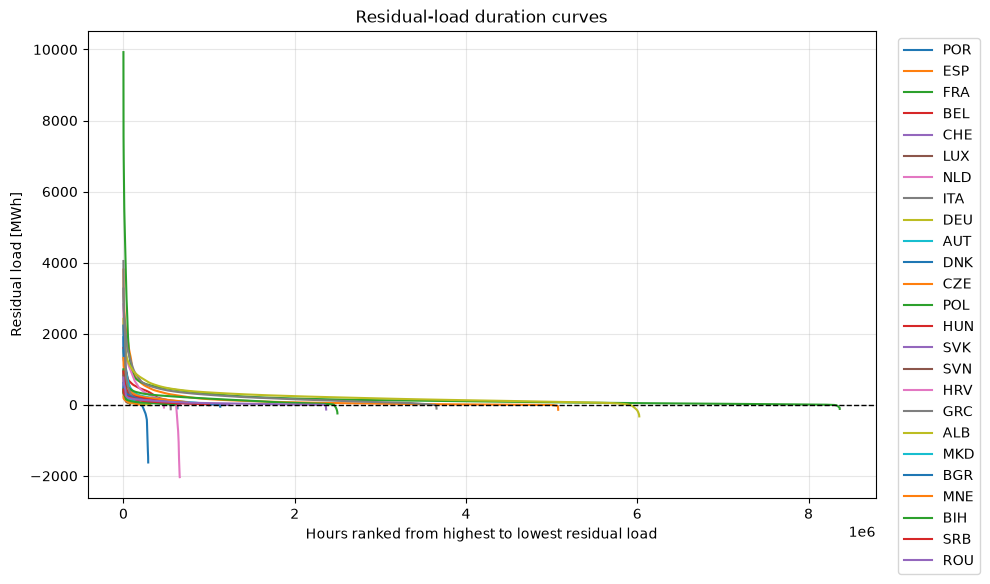

In [26]:
areas = ['POR', 'ESP', 'FRA', 'BEL', 'CHE', 'LUX', 'NLD', 'ITA', 'DEU', 'AUT', 'DNK',
 'CZE', 'POL', 'HUN', 'SVK', 'SVN', 'HRV', 'GRC', 'ALB', 'MKD', 'BGR', 'MNE',
 'BIH', 'SRB', 'ROU']
plot_duration_curves(dataset_residual, freq='Hours', areas=areas)


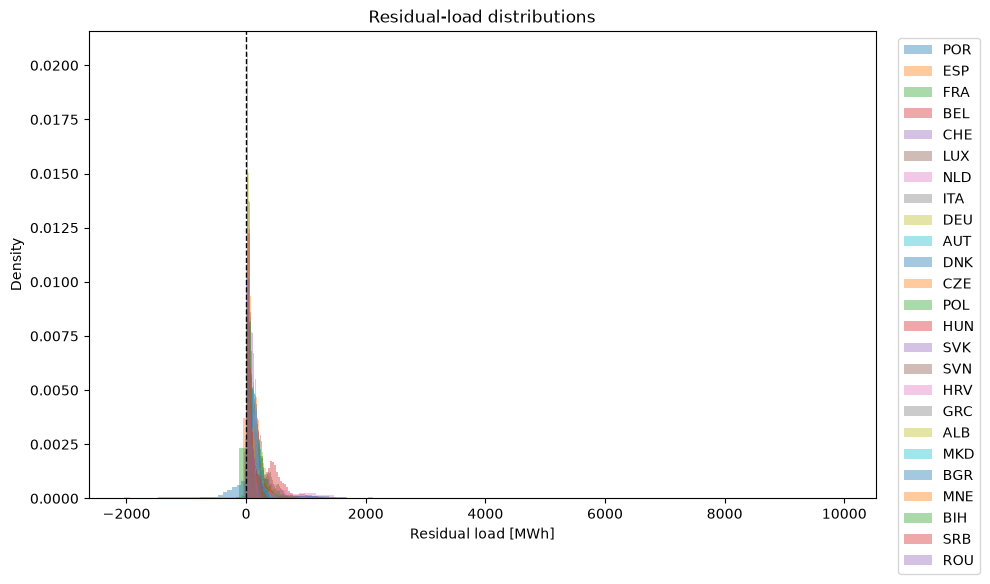

In [48]:
plot_histograms(dataset_residual, areas, density=True)

(np.float64(-180.0), np.float64(180.0))


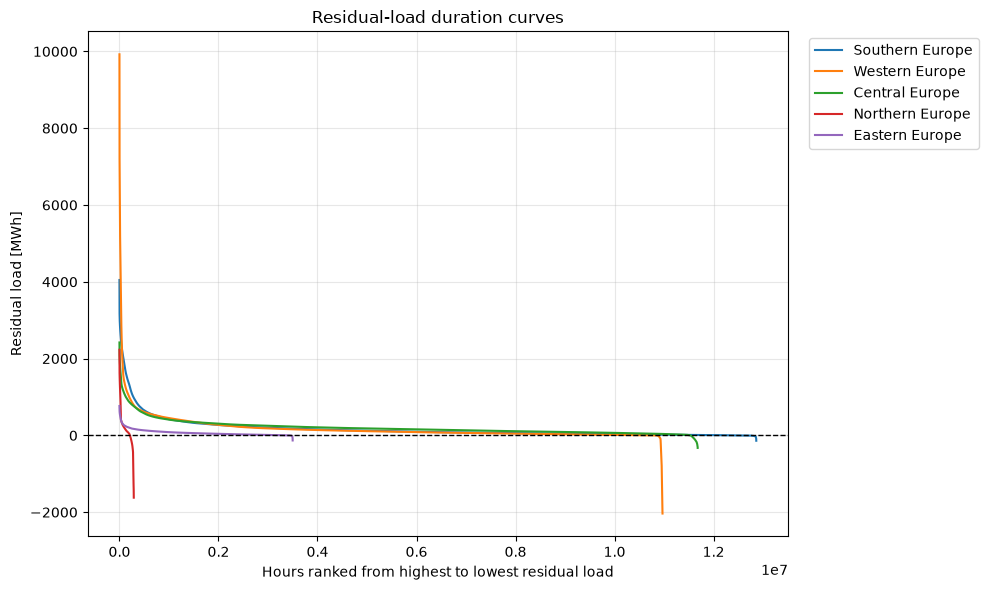

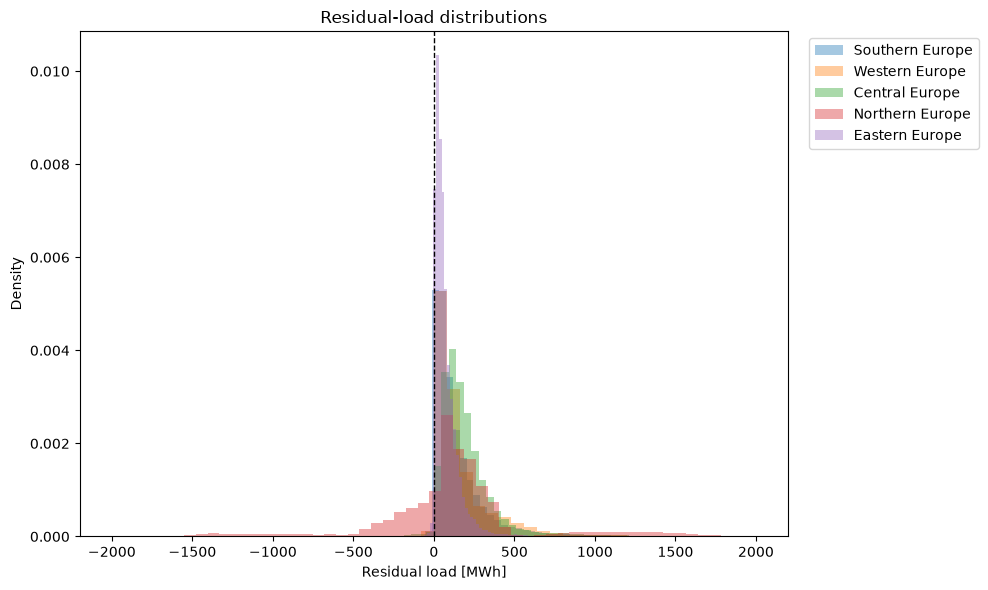

In [64]:
plot_duration_curves(dataset_residual, freq='Hours', areas=list(dataset_residual['region'].unique()), area_col='region')
plot_histograms(dataset_residual, areas=list(dataset_residual['region'].unique()), area_col='region', density=True)

Northern Europe has the widest spread due to its latitude, large surplus during summer and large residual over winter. 
Central and western europe has residual than others.  (lattitude + prosperity--busier city requires more)
Southern Europe concentrated in the middle. (lattitude)

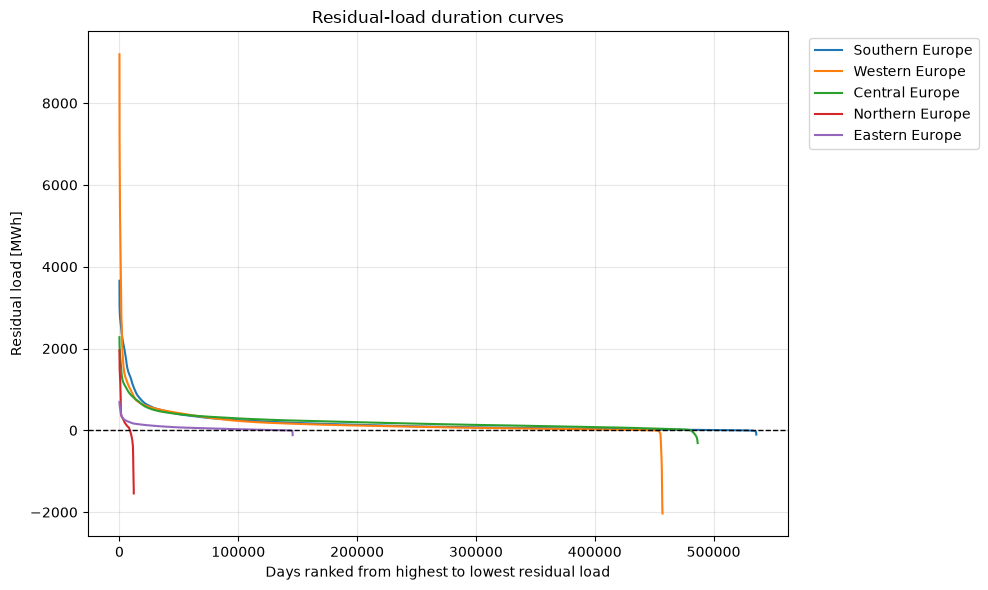

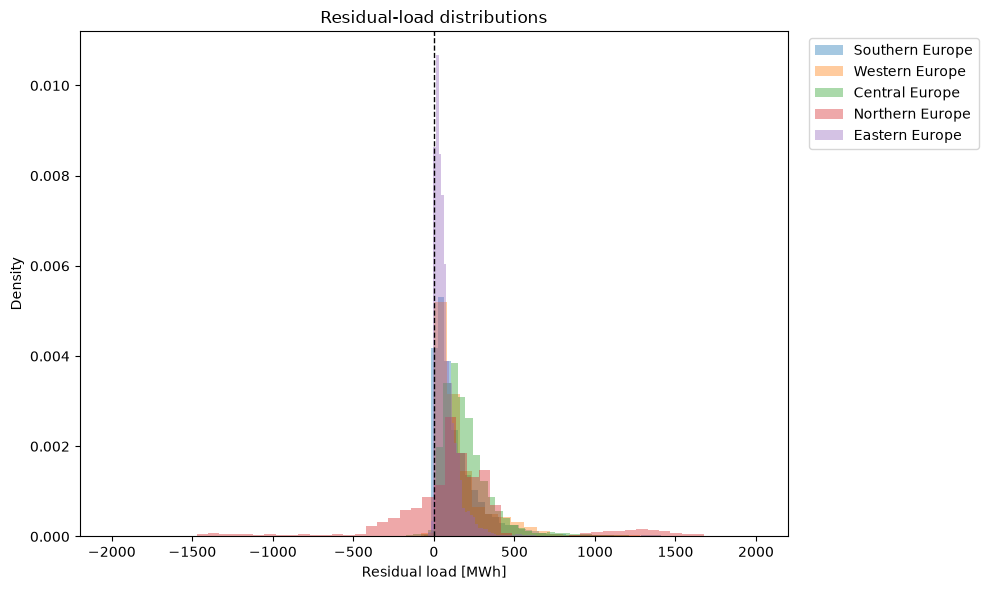

In [63]:
plot_duration_curves(daily, freq='Days', areas=list(dataset_residual['region'].unique()), area_col='region')
plot_histograms(daily, areas=list(dataset_residual['region'].unique()), area_col='region', density=True)

Above is daily. Below is Monthly--- Only Northern, Souther and Western Europe has surplus.

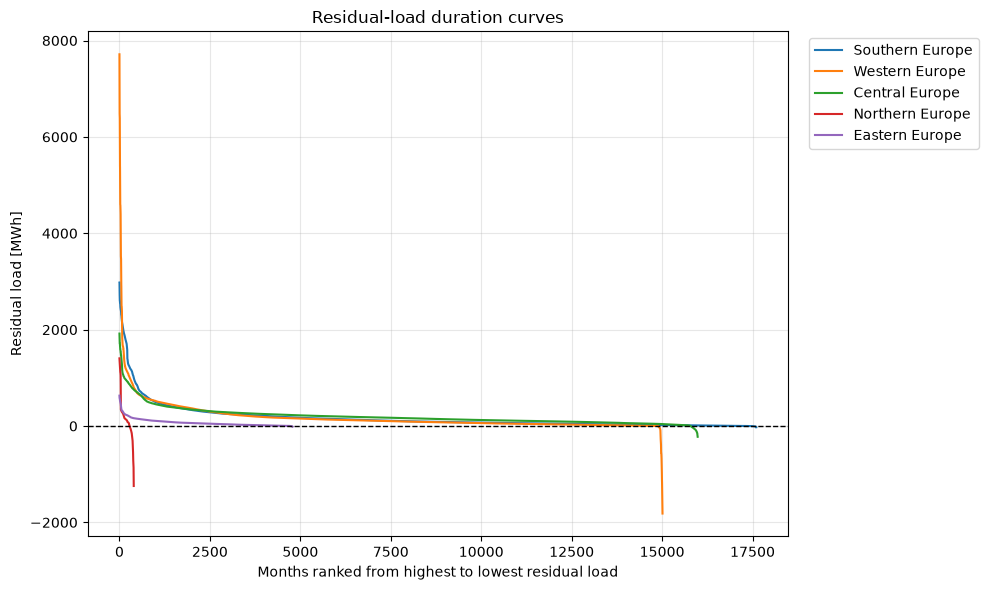

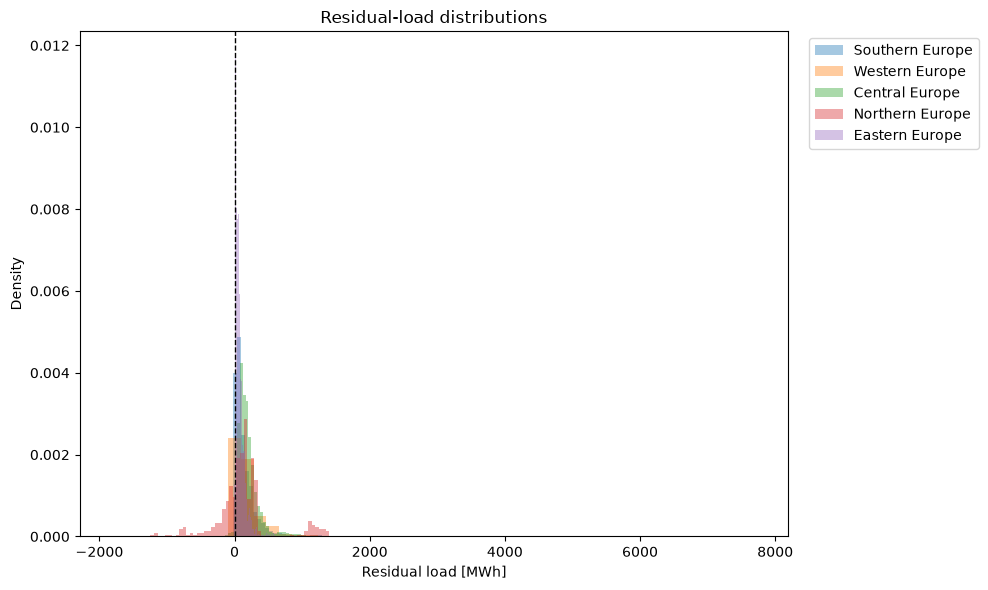

In [30]:
plot_duration_curves(monthly, freq='Months', areas=list(dataset_residual['region'].unique()), area_col='region')
plot_histograms(monthly, areas=list(dataset_residual['region'].unique()), area_col='region', density=True)

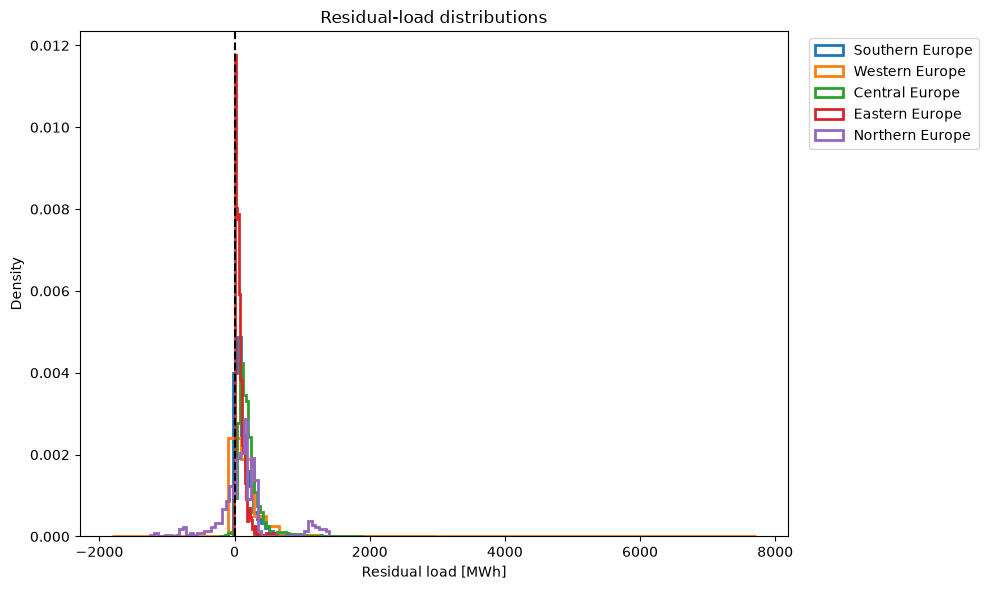

In [31]:
def plot_histograms_norm(df, areas, area_col="country", r_col="residual_MWh",
                    bins=50):
    fig, ax = plt.subplots(figsize=(10, 6))

    for area in areas:
        r = df[df[area_col] == area][r_col]

        ax.hist(
            r,
            bins=bins,
            density=True,
            histtype="step",
            linewidth=2,
            label=area
        )

    ax.axvline(0, color="black", linestyle="--")
    ax.set_title("Residual-load distributions")
    ax.set_xlabel("Residual load [MWh]")
    ax.set_ylabel("Density")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()
    plt.show()
plot_histograms_norm(monthly, areas=list(monthly['region'].unique()), area_col='region')

#### Energy region

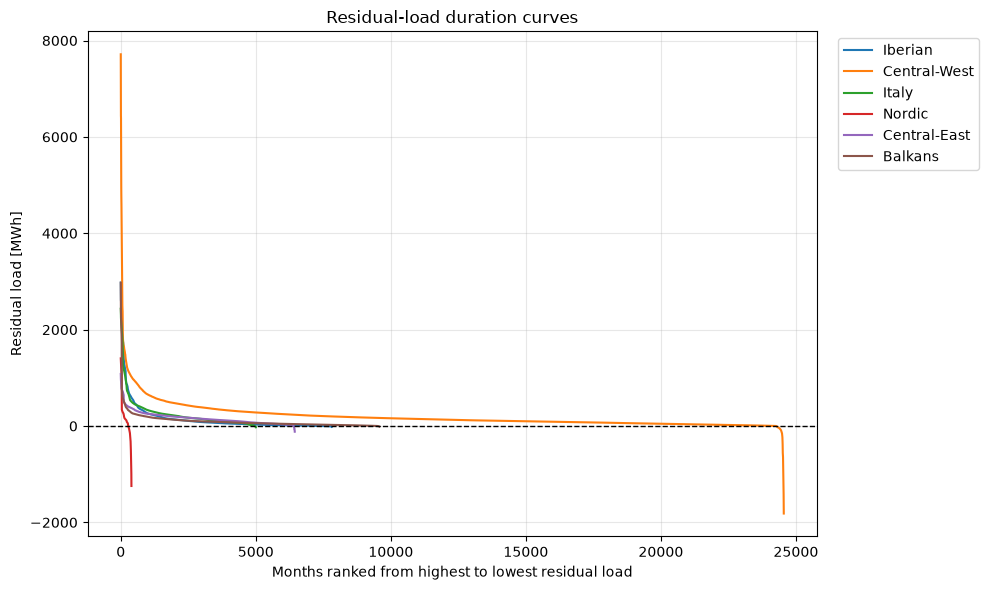

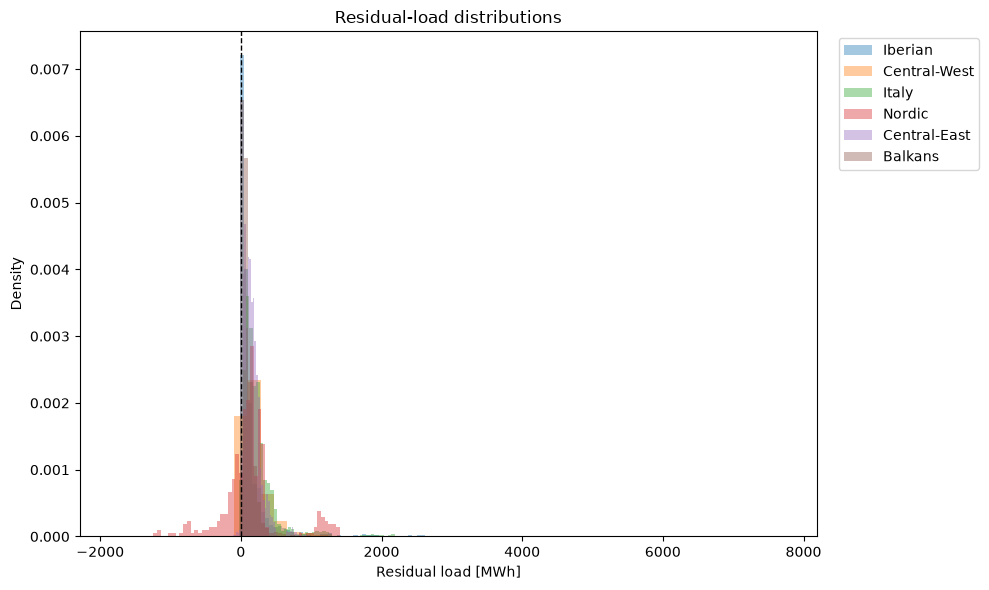

In [32]:
plot_duration_curves(monthly, freq='Months', areas=list(dataset_residual['e_region'].unique()), area_col='e_region')
plot_histograms(monthly, areas=list(dataset_residual['e_region'].unique()), area_col='e_region', density=True)

### Stress Events

In [33]:
# stress events
def stress_events(df, area_col="country", time_col="Time", r_col="residual_MWh", q=0.90):
    events = []

    for area, g in df.sort_values(time_col).groupby(area_col):
        threshold = g[r_col].quantile(q)
        stress = g[g[r_col] > threshold].copy()
        stress["stress_threshold"] = threshold
        events.append(stress)

    return pd.concat(events)

In [34]:
stress_events(dataset_residual)

,Time,ID,latitude,longitude,country,solar_scaled_MWh,wind_scaled_MWh,demand_MWh,supply_scaled_MWh,residual_MWh,region,e_region,stress_threshold
1260,2012-01-01 00:00:00+00:00,1277,40.844443,20.266280,ALB,0.0,0.820390,221.1898,0.820390,220.369410,Southern Europe,Balkans,178.547536
1261,2012-01-01 00:00:00+00:00,1278,41.419464,19.859433,ALB,0.0,0.341029,290.9656,0.341029,290.624571,Southern Europe,Balkans,178.547536
2754,2012-01-01 01:00:00+00:00,1277,40.844443,20.266280,ALB,0.0,0.775189,218.5729,0.775189,217.797711,Southern Europe,Balkans,178.547536
2755,2012-01-01 01:00:00+00:00,1278,41.419464,19.859433,ALB,0.0,0.335149,287.5231,0.335149,287.187951,Southern Europe,Balkans,178.547536
4248,2012-01-01 02:00:00+00:00,1277,40.844443,20.266280,ALB,0.0,0.761629,205.7616,0.761629,204.999971,Southern Europe,Balkans,178.547536
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39291922,2014-12-31 19:00:00+00:00,1220,46.407274,15.761697,SVN,0.0,0.062031,729.1614,0.062031,729.099369,Southern Europe,Balkans,466.628654
39293416,2014-12-31 20:00:00+00:00,1220,46.407274,15.761697,SVN,0.0,0.047262,683.9808,0.047262,683.933538,Southern Europe,Balkans,466.628654
39294910,2014-12-31 21:00:00+00:00,1220,46.407274,15.761697,SVN,0.0,0.087139,655.8642,0.087139,655.777061,Southern Europe,Balkans,466.628654
39296404,2014-12-31 22:00:00+00:00,1220,46.407274,15.761697,SVN,0.0,0.193478,625.0352,0.193478,624.841722,Southern Europe,Balkans,466.628654


In [35]:
# worst hours or days
dataset_residual["date"] = pd.to_datetime(dataset_residual["Time"]).dt.date

worst_days = (
    dataset_residual.groupby(["country", "date"])["residual_MWh"]
      .agg(["mean", "median", "max", "sum"])
      .reset_index()
      .sort_values(["country", "max"], ascending=[True, False])
)

In [36]:
idx = daily.groupby("country")["residual_MWh"].idxmax()

country_worst_day = (
    daily.loc[idx]
         .sort_values("residual_MWh", ascending=False)
         .reset_index(drop=True)
)

country_worst_day

,Time,ID,demand_MWh,supply_MWh,solar_MWh,wind_MWh,residual_MWh,latitude,longitude,country,region,e_region
0,2012-02-08 00:00:00+00:00,296,9185.146100,8.016120,1.181967,6.834153,9194.051199,48.844170,2.420441,FRA,Western Europe,Central-West
1,2012-07-16 00:00:00+00:00,1257,3561.891179,99.525103,25.705480,73.819623,3656.815862,38.037196,23.860707,GRC,Southern Europe,Balkans
2,2012-02-13 00:00:00+00:00,111,3170.643346,19.970474,2.109959,17.860514,3426.500918,41.464478,2.196265,ESP,Southern Europe,Iberian
3,2012-02-14 00:00:00+00:00,666,2644.055900,1.278484,1.204588,0.073896,2951.875085,45.488570,9.280486,ITA,Southern Europe,Italy
4,2013-01-24 00:00:00+00:00,617,2389.907708,76.133675,1.218617,74.915059,2588.608305,52.399858,4.745116,NLD,Western Europe,Central-West
5,2014-12-03 00:00:00+00:00,808,2106.161742,3.209230,0.247357,2.961873,2277.184533,52.459904,13.436623,DEU,Central Europe,Central-West
6,2012-02-06 00:00:00+00:00,1511,1864.960450,73.575740,3.874370,69.701370,1958.375851,54.909546,12.037968,DNK,Northern Europe,Nordic
7,2012-02-03 00:00:00+00:00,6,1557.230775,9.553980,3.424578,6.129403,1652.430976,41.227376,-8.314878,POR,Southern Europe,Iberian
8,2012-02-07 00:00:00+00:00,543,1448.017275,7.398840,0.868807,6.530033,1480.471566,51.002701,4.237073,BEL,Western Europe,Central-West
9,2012-02-07 00:00:00+00:00,999,1345.358679,15.246818,0.342783,14.904036,1426.654886,48.134094,16.340807,AUT,Central Europe,Central-West


In [37]:
idx = daily.groupby("region")["residual_MWh"].idxmax()

region_worst_day = (
    daily.loc[idx]
         .sort_values("residual_MWh", ascending=False)
         .reset_index(drop=True)
)
region_worst_day

,Time,ID,demand_MWh,supply_MWh,solar_MWh,wind_MWh,residual_MWh,latitude,longitude,country,region,e_region
0,2012-02-08 00:00:00+00:00,296,9185.146100,8.016120,1.181967,6.834153,9194.051199,48.844170,2.420441,FRA,Western Europe,Central-West
1,2012-07-16 00:00:00+00:00,1257,3561.891179,99.525103,25.705480,73.819623,3656.815862,38.037196,23.860707,GRC,Southern Europe,Balkans
2,2014-12-03 00:00:00+00:00,808,2106.161742,3.209230,0.247357,2.961873,2277.184533,52.459904,13.436623,DEU,Central Europe,Central-West
3,2012-02-06 00:00:00+00:00,1511,1864.960450,73.575740,3.874370,69.701370,1958.375851,54.909546,12.037968,DNK,Northern Europe,Nordic
4,2012-02-09 00:00:00+00:00,1419,675.134158,4.775260,3.785768,0.989492,697.004888,44.534745,26.095031,ROU,Eastern Europe,Balkans


### Sensitivity to scaling

In [38]:
# ----------------------------------------------
# Sensitivity scenarios using dataset_residual logic
# ----------------------------------------------

scenarios = [
    {"name": "baseline", "multiplier": 1.0},
    {"name": "1.5x", "multiplier": 1.5},
    {"name": "2x", "multiplier": 2.0},
    {"name": "3x", "multiplier": 3.0},
]

results = []

for s in scenarios:
    tmp = dataset.copy()

    alpha_w = s["multiplier"] * a_w
    alpha_s = s["multiplier"] * a_s

    tmp = tmp.assign(
        solar_scaled_MWh=lambda df: alpha_s * df["solar_MWh"],
        wind_scaled_MWh=lambda df: alpha_w * df["wind_MWh"],
        supply_scaled_MWh=lambda df: df["solar_scaled_MWh"] + df["wind_scaled_MWh"],
        residual_MWh=lambda df: df["demand_MWh"] - df["supply_scaled_MWh"],
    )

    tmp_residual = tmp[
        [
            "Time",
            "ID",
            "latitude",
            "longitude",
            "country",
            "solar_scaled_MWh",
            "wind_scaled_MWh",
            "demand_MWh",
            "supply_scaled_MWh",
            "residual_MWh",
        ]
    ].copy()

    metrics = residual_load_metrics(tmp_residual)

    metrics["scenario"] = s["name"]
    metrics["alpha_w"] = alpha_w
    metrics["alpha_s"] = alpha_s
    metrics["multiplier"] = s["multiplier"]

    results.append(metrics)

scenario_metrics = pd.concat(results, ignore_index=True)

In [39]:
len(scenario_metrics['country'])

100

In [40]:
scenario_metrics

,country,mean_R,median_R,p90_R,p95_R,p99_R,max_R,min_R,std_R,surplus_share,...,mean_negative_R,total_surplus,mean_abs_ramp,p95_abs_ramp,max_up_ramp,max_down_ramp,scenario,alpha_w,alpha_s,multiplier
0,ALB,58.048832,33.723140,178.547536,221.071488,294.142108,386.987874,-10.080537,67.603282,0.004423,...,-2.370582,3.309332e+03,48.652012,195.561134,383.490355,-319.992725,baseline,0.05,0.01,1.0
1,AUT,214.549069,145.898128,430.845894,729.216566,1190.298806,1534.171336,13.032622,224.495005,0.000000,...,NaN,-0.000000e+00,191.077268,781.366799,1320.812638,-1411.514737,baseline,0.05,0.01,1.0
2,BEL,366.838565,335.860701,681.838504,914.723474,1219.275011,1603.520806,-20.477719,261.630420,0.000120,...,-7.340629,5.578878e+02,229.871617,609.524169,872.680191,-1029.824039,baseline,0.05,0.01,1.0
3,BGR,95.893991,74.631325,220.382850,272.826555,370.754666,617.528701,-52.938446,82.472435,0.026401,...,-8.445315,2.521855e+05,87.421476,265.661154,589.362288,-548.817377,baseline,0.05,0.01,1.0
4,BIH,64.170677,52.011903,122.043401,158.587746,302.109039,426.593406,7.324985,55.513321,0.000000,...,NaN,-0.000000e+00,45.556048,214.070256,397.597860,-367.976752,baseline,0.05,0.01,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,POR,192.274159,90.773312,575.714065,978.017530,1386.301739,1886.232649,-604.376144,297.114036,0.075291,...,-35.456005,1.685259e+06,267.491575,1070.652033,1662.708405,-1753.866159,3x,0.15,0.03,3.0
96,ROU,48.324657,32.856512,122.008703,152.045270,403.717021,763.873351,-478.648694,71.667779,0.085837,...,-28.297082,5.750193e+06,57.340857,150.348955,743.253519,-749.926058,3x,0.15,0.03,3.0
97,SRB,77.692133,57.206381,174.996533,219.942361,289.677528,428.792472,-94.510789,63.980229,0.006504,...,-16.569743,1.077199e+05,57.450610,178.167379,362.653687,-361.915499,3x,0.15,0.03,3.0
98,SVK,117.327097,104.728393,188.686328,223.253174,393.841624,513.054842,-123.721885,68.739855,0.003966,...,-22.463464,5.858471e+04,66.709834,237.913968,453.597733,-433.329213,3x,0.15,0.03,3.0


### Stress Index

A simple interpretable index could combine peak demand, ramping, and scarcity/surplus frequency:

$$
\mathrm{SI}_c
=
z\!\left(P_{95}(R_c)\right)
+
z\!\left(P_{95}\left(\left|\Delta R_c\right|\right)\right)
-
z\!\left(U_c\right)
$$

where R is residual load, U is surplus share

In [76]:
from sklearn.preprocessing import StandardScaler

def add_stress_index(metrics):
    cols = ["p95_R", "p95_abs_ramp", "stress_share_p90", "surplus_share"]

    x = metrics[cols].copy()
    x["surplus_share"] = -x["surplus_share"]

    z = StandardScaler().fit_transform(x)

    metrics = metrics.copy()
    metrics["stress_index"] = z.sum(axis=1)
    return metrics.sort_values("stress_index", ascending=False)

In [77]:
metrics= residual_load_metrics(daily)
stress_metrics_country= add_stress_index(metrics)
stress_metrics_country

,country,mean_R,median_R,p90_R,p95_R,p99_R,max_R,min_R,std_R,surplus_share,stress_share_p90,mean_positive_R,total_positive_R,mean_negative_R,total_surplus,mean_abs_ramp,p95_abs_ramp,max_up_ramp,max_down_ramp,stress_index
11,GRC,238.411934,93.629147,480.854863,869.594828,2475.447919,3656.815862,-98.337630,465.389388,0.004388,0.100017,239.545791,5.489192e+06,-18.838708,1.902710e+03,318.863768,1977.789828,3300.659355,-3593.359233,3.778050
20,POR,225.198089,114.780556,618.403281,1042.355747,1415.818584,1652.430976,-82.469376,310.088851,0.002395,0.100023,225.752945,5.923983e+06,-5.912720,3.725014e+02,242.219429,1244.794953,1543.918294,-1647.079711,3.026625
18,NLD,383.513700,274.321029,1157.276912,1388.072365,1959.860931,2588.608305,-2033.870148,562.488918,0.069234,0.100000,468.990762,1.196067e+07,-765.627843,1.452396e+06,413.515735,1643.841392,2458.426171,-2436.352770,2.898753
24,SVN,239.109659,185.442310,506.504729,554.940601,624.893747,740.902819,52.307312,150.446369,0.000000,0.100104,239.109659,1.834449e+06,NaN,-0.000000e+00,197.254701,375.235429,501.776555,-480.660784,2.316927
2,BEL,380.038092,362.413099,693.083301,940.241177,1231.828249,1480.471566,14.314127,266.041234,0.000000,0.100023,380.038092,9.996522e+06,NaN,-0.000000e+00,236.820518,636.007159,993.764814,-950.010731,1.559625
1,AUT,227.004934,159.595642,460.005166,817.874880,1185.709123,1426.654886,17.116643,234.072971,0.000000,0.100010,227.004934,8.956707e+06,NaN,-0.000000e+00,184.704305,856.316304,1358.371952,-1280.421545,1.262578
14,ITA,271.871709,187.744012,511.435768,787.647026,2018.123609,2951.875085,-103.052260,326.062808,0.014369,0.100004,275.948669,4.143507e+07,-7.788373,1.704875e+04,269.115785,1109.574894,2348.373384,-2649.010441,1.222087
16,MKD,152.563679,143.936958,246.350984,286.671583,366.281853,427.324645,47.721719,71.939940,0.000000,0.100104,152.563679,1.170469e+06,NaN,-0.000000e+00,82.508599,164.878914,270.296258,-232.992644,1.108122
17,MNE,70.244480,62.556712,130.365666,150.655910,179.663123,216.508170,16.854721,41.671520,0.000000,0.100104,70.244480,5.389157e+05,NaN,-0.000000e+00,46.614901,125.749835,125.100517,-179.143440,0.629624
15,LUX,119.793901,72.279800,263.271058,284.678761,306.287738,323.890085,16.743386,90.078715,0.000000,0.100061,119.793901,3.938823e+05,NaN,-0.000000e+00,130.760823,234.338990,277.823437,-227.443447,-0.045460


In [72]:
stress_metrics = stress_metrics_country[['country', 'stress_index']].copy()
stress_metrics

,country,stress_index
11,GRC,3.778050
20,POR,3.026625
18,NLD,2.898753
24,SVN,2.316927
2,BEL,1.559625
1,AUT,1.262578
14,ITA,1.222087
16,MKD,1.108122
17,MNE,0.629624
15,LUX,-0.045460


In [44]:
metrics= residual_load_metrics(daily, area_col='region')
stress_metrics_region = add_stress_index(metrics)
stress_metrics_region 

,region,mean_R,median_R,p90_R,p95_R,p99_R,max_R,min_R,std_R,surplus_share,stress_share_p90,mean_positive_R,total_positive_R,mean_negative_R,total_surplus,mean_abs_ramp,p95_abs_ramp,max_up_ramp,max_down_ramp,stress_index
2,Northern Europe,147.743522,123.355539,408.667818,1226.924006,1552.571084,1958.375851,-1542.372067,471.117608,0.266506,0.100033,318.629959,2.817645e+06,-322.579779,1.036449e+06,441.705633,1528.286434,1695.604151,-2111.373609,3.623228
3,Southern Europe,177.150673,88.427548,378.965729,577.561862,1776.489755,3656.815862,-103.052260,297.681281,0.021989,0.100001,181.273588,9.501618e+07,-6.223349,7.334216e+04,201.243577,786.349377,3415.555808,-3433.264545,-0.165802
4,Western Europe,188.323588,100.891076,442.637302,596.146612,1340.046183,9194.051199,-2033.870148,377.309806,0.010492,0.100002,193.701408,8.759894e+07,-318.881623,1.529037e+06,205.133964,604.468024,8946.875186,-9038.480049,-0.366442
0,Central Europe,214.987776,168.301029,400.908105,547.430436,1078.183137,2277.184533,-311.896677,201.846976,0.012515,0.100001,218.832664,1.051565e+08,-88.394711,5.383238e+05,169.453350,582.702652,2164.309924,-2161.534920,-0.625838
1,Eastern Europe,71.469849,50.179453,155.345790,214.838100,384.109828,697.004888,-117.843496,77.225113,0.012973,0.100001,72.572568,1.044152e+07,-12.430661,2.350638e+04,68.900839,222.612183,681.127406,-638.605513,-2.465146


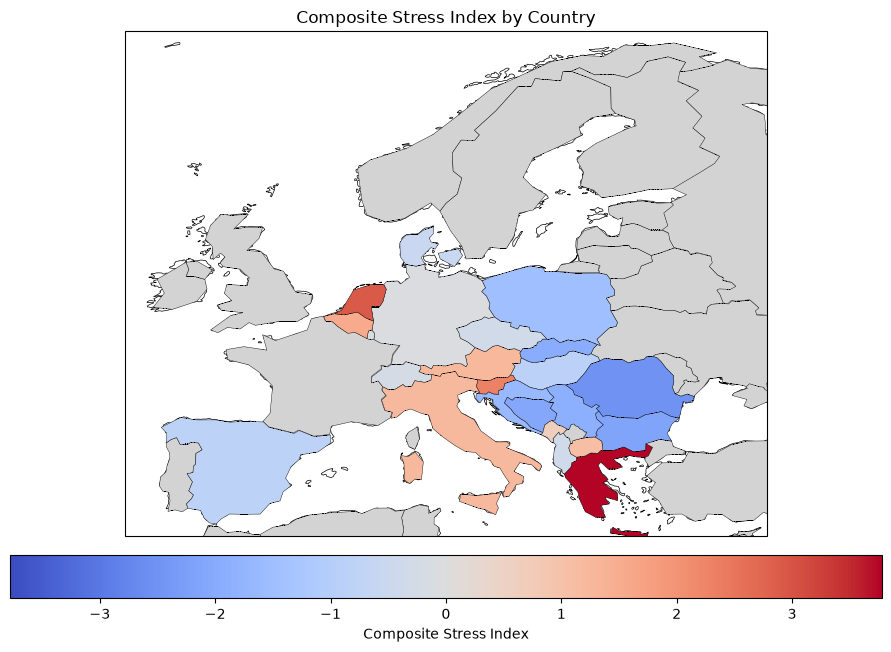

In [78]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
import pandas as pd

# Make sure stress_index is numeric
stress_metrics_country["stress_index"] = pd.to_numeric(
    stress_metrics_country["stress_index"],
    errors="coerce"
)

# Natural Earth countries
shpfilename = shpreader.natural_earth(
    resolution="110m",
    category="cultural",
    name="admin_0_countries"
)

reader = shpreader.Reader(shpfilename)

# Your countries are ISO3 codes: FRA, DEU, ESP, etc.
stress = dict(zip(
    stress_metrics_country["country"],
    stress_metrics_country["stress_index"]
))

# Symmetric colour scale around 0
vmax = stress_metrics_country["stress_index"].abs().max()

norm = mpl.colors.TwoSlopeNorm(
    vmin=-vmax,
    vcenter=0,
    vmax=vmax
)

cmap = plt.cm.coolwarm

fig = plt.figure(figsize=(15, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([-12, 35, 35, 72], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.5)

for country in reader.records():

    iso3 = country.attributes["ISO_A3"]

    if iso3 in stress:
        color = cmap(norm(stress[iso3]))
    else:
        color = "lightgrey"

    ax.add_geometries(
        [country.geometry],
        ccrs.PlateCarree(),
        facecolor=color,
        edgecolor="black",
        linewidth=0.3
    )

# Colour bar
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(
    sm,
    ax=ax,
    orientation="horizontal",
    pad=0.03,
    shrink=0.75
)

cbar.set_label("Composite Stress Index")

plt.title("Composite Stress Index by Country")
plt.show()

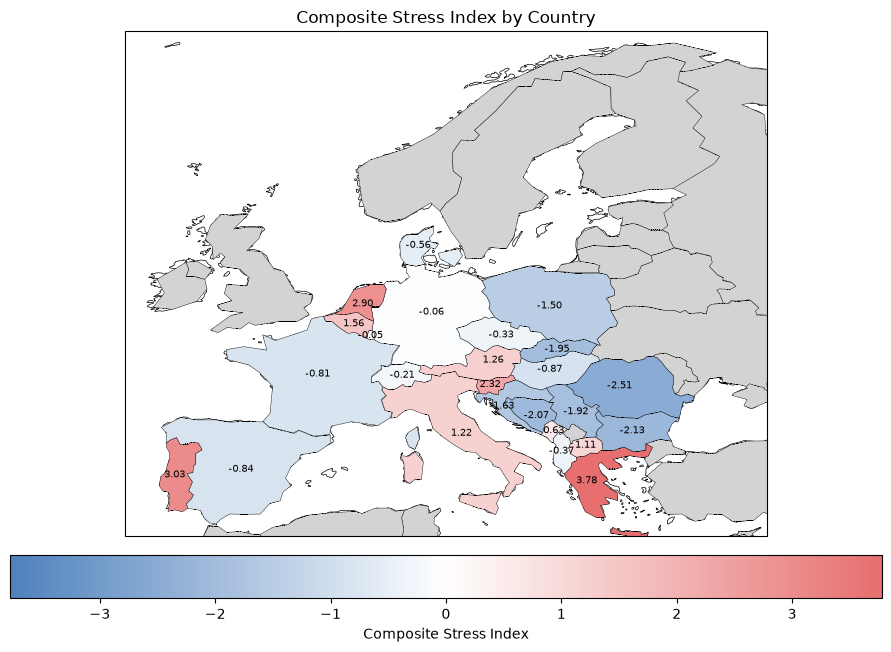

In [81]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd

stress_metrics_country["stress_index"] = pd.to_numeric(
    stress_metrics_country["stress_index"],
    errors="coerce"
)

shpfilename = shpreader.natural_earth(
    resolution="110m",
    category="cultural",
    name="admin_0_countries"
)

reader = shpreader.Reader(shpfilename)

stress = dict(zip(
    stress_metrics_country["country"],
    stress_metrics_country["stress_index"]
))

vmax = stress_metrics_country["stress_index"].abs().max()

norm = mpl.colors.TwoSlopeNorm(
    vmin=-vmax,
    vcenter=0,
    vmax=vmax
)

# Softer diverging colour scale
cmap = LinearSegmentedColormap.from_list(
    "pastel_bwr",
    [
        "#4F81BD",   # stronger cornflower blue
        "#FFFFFF",
        "#E76F6F"    # salmon red
    ],
    N=256
)

fig = plt.figure(figsize=(15, 8))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.set_extent([-12, 35, 35, 72], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.5)

for country in reader.records():

    iso3 = country.attributes["ISO_A3"]
    adm = country.attributes["ADM0_A3"]
    if country.attributes.get("NAME") == "Portugal":
        iso3 = "POR"

    if iso3 in stress:
        value = stress[iso3]
        color = cmap(norm(value))
    elif adm in stress: 
        value = stress[adm]
        color = cmap(norm(value))
    elif "Por" in stress:
        value = stress["Por"]
        color = cmap(norm(value))
    else:
        value = None
        color = "lightgrey"

    ax.add_geometries(
        [country.geometry],
        ccrs.PlateCarree(),
        facecolor=color,
        edgecolor="black",
        linewidth=0.3
    )

    # Add stress index label
    if value is not None:
        point = country.geometry.representative_point()
        x, y = point.x, point.y

        ax.text(
            x,
            y,
            f"{value:.2f}",
            transform=ccrs.PlateCarree(),
            ha="center",
            va="center",
            fontsize=7,
            color="black"
        )

sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = plt.colorbar(
    sm,
    ax=ax,
    orientation="horizontal",
    pad=0.03,
    shrink=0.75
)

cbar.set_label("Composite Stress Index")

plt.title("Composite Stress Index by Country")
plt.show()


### Time Series

c:\Users\xiang\Downloads\Data challende\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\xiang\Downloads\Data challende\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\xiang\Downloads\Data challende\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


          Model           MAE          RMSE            R2  \
0  Weekly naive  6.987058e+03  9.607615e+03  4.813242e-01   
1       SARIMAX  1.041826e+50  8.706103e+50 -4.259046e+93   

   Prediction interval coverage (%)  Mean interval width  
0                               NaN                  NaN  
1                             100.0         6.658335e+56  
        Date       Observed      Predicted       Lower_95       Upper_95  \
0 2013-01-01  102108.429667  102108.429667  102108.427182  102108.432153   
1 2013-01-02  130887.727630  130887.727630  130887.724250  130887.731010   
2 2013-01-03  135175.914251  135175.914251  135175.909506  135175.918996   
3 2013-01-04  136051.198099  136051.198099  136051.191226  136051.204972   
4 2013-01-05  123716.751663  123716.751663  123716.741564  123716.761762   

          Error  
0 -7.130438e-10  
1  1.004082e-09  
2  1.920853e-09  
3  2.706656e-09  
4  3.710738e-09  


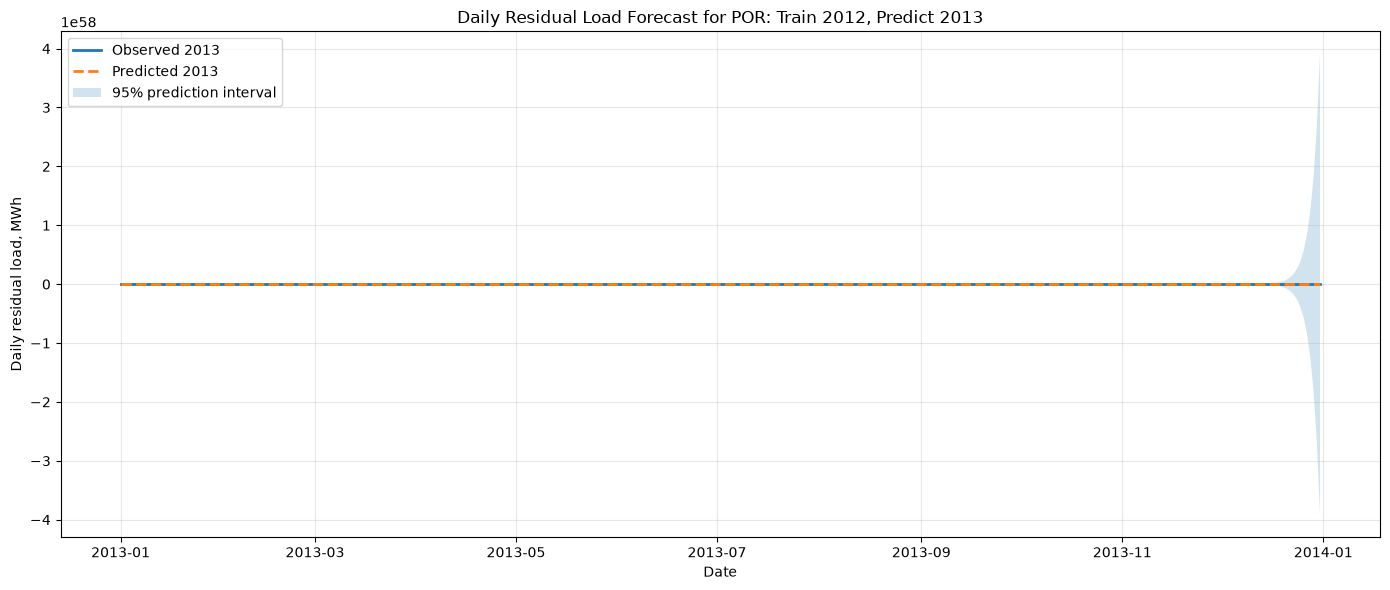

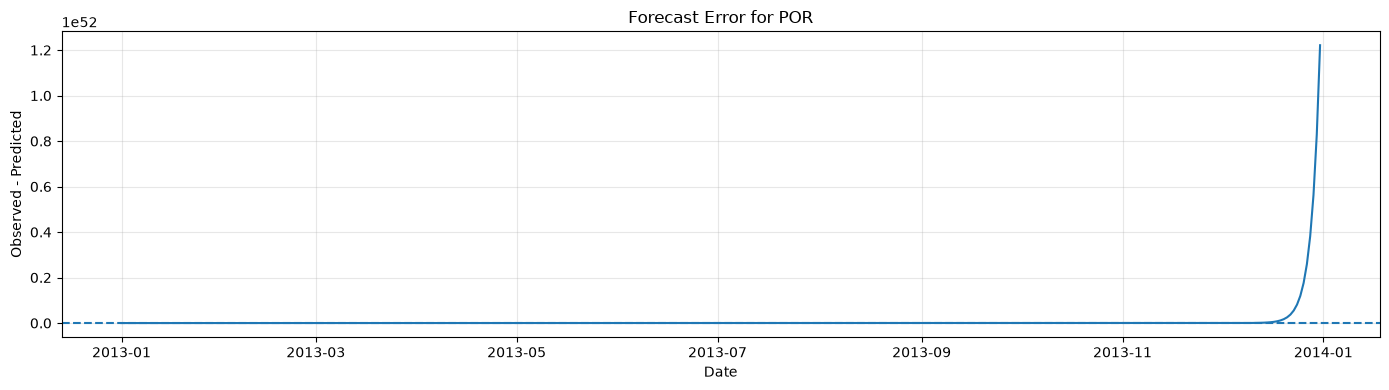

    Month           MAE          Bias          RMSE
0       1  7.802288e-06  7.802242e-06  1.899898e-05
1       2  4.440541e-01  4.440541e-01  1.027792e+00
2       3  6.593073e+04  6.593073e+04  1.605659e+05
3       4  7.601927e+09  7.601927e+09  1.821253e+10
4       5  1.209301e+15  1.209301e+15  2.945099e+15
5       6  1.394345e+20  1.394345e+20  3.340541e+20
6       7  2.218099e+25  2.218099e+25  5.401899e+25
7       8  3.646118e+30  3.646118e+30  8.879660e+30
8       9  4.204038e+35  4.204038e+35  1.007194e+36
9      10  6.687708e+40  6.687708e+40  1.628707e+41
10     11  7.711043e+45  7.711043e+45  1.847395e+46
11     12  1.226659e+51  1.226659e+51  2.987372e+51


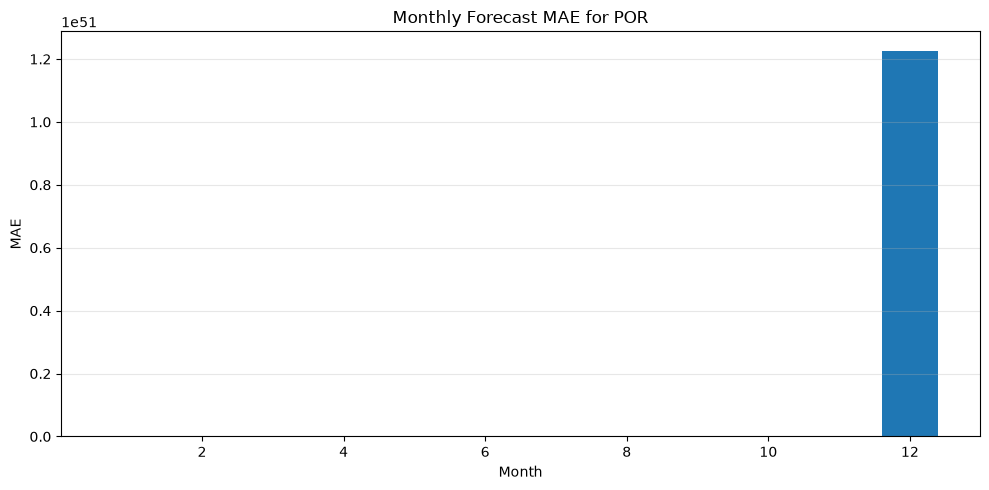

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ============================================================
# 0. SETTINGS
# ============================================================

df = dataset_residual.copy()   # change if your dataframe has another name                # choose country
target_col = "residual_MWh"

# ============================================================
# 1. PREPARE DAILY DATA
# ============================================================

df["Time"] = pd.to_datetime(df["Time"], utc=True)

country_df = df[df["country"] == country].copy()

daily = (
    country_df
    .groupby(pd.Grouper(key="Time", freq="D"))
    .agg({
        "residual_MWh": "sum",
        "demand_MWh": "sum",
        "solar_scaled_MWh": "sum",
        "wind_scaled_MWh": "sum",
        "supply_scaled_MWh": "sum"
    })
    .reset_index()
)

daily = daily.sort_values("Time")
daily = daily.set_index("Time")

# remove timezone for statsmodels
daily.index = daily.index.tz_localize(None)

# ============================================================
# 2. TRAIN / TEST SPLIT
# Train on 2012, predict 2013
# ============================================================

train = daily[daily.index.year == 2012]
test = daily[daily.index.year == 2013]

y_train = train[target_col]
y_test = test[target_col]

# Exogenous variables
exog_cols = [
    "demand_MWh",
    "solar_scaled_MWh",
    "wind_scaled_MWh"
]

X_train = train[exog_cols]
X_test = test[exog_cols]

# ============================================================
# 3. BASELINE MODEL: WEEKLY NAIVE
# y_hat(t) = y(t-7)
# ============================================================

full_series = daily[target_col]

weekly_naive_pred = full_series.shift(7).loc[test.index]

# Drop missing values if needed
valid_idx = weekly_naive_pred.dropna().index

baseline_mae = mean_absolute_error(
    y_test.loc[valid_idx],
    weekly_naive_pred.loc[valid_idx]
)

baseline_rmse = np.sqrt(mean_squared_error(
    y_test.loc[valid_idx],
    weekly_naive_pred.loc[valid_idx]
))

baseline_r2 = r2_score(
    y_test.loc[valid_idx],
    weekly_naive_pred.loc[valid_idx]
)

# ============================================================
# 4. SARIMAX MODEL
# Daily data: weekly seasonality = 7
# ============================================================

model = SARIMAX(
    y_train,
    exog=X_train,
    order=(2, 1, 2),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
)

results = model.fit(disp=False)

forecast = results.get_forecast(
    steps=len(test),
    exog=X_test
)

sarimax_pred = forecast.predicted_mean
conf_int = forecast.conf_int(alpha=0.05)

lower = conf_int.iloc[:, 0]
upper = conf_int.iloc[:, 1]

# ============================================================
# 5. EVALUATION
# ============================================================

sarimax_mae = mean_absolute_error(y_test, sarimax_pred)

sarimax_rmse = np.sqrt(mean_squared_error(y_test, sarimax_pred))

sarimax_r2 = r2_score(y_test, sarimax_pred)

coverage = np.mean((y_test >= lower) & (y_test <= upper)) * 100

mean_interval_width = np.mean(upper - lower)

results_table = pd.DataFrame({
    "Model": ["Weekly naive", "SARIMAX"],
    "MAE": [baseline_mae, sarimax_mae],
    "RMSE": [baseline_rmse, sarimax_rmse],
    "R2": [baseline_r2, sarimax_r2],
    "Prediction interval coverage (%)": [np.nan, coverage],
    "Mean interval width": [np.nan, mean_interval_width]
})

print(results_table)

# ============================================================
# 6. SAVE FORECAST RESULTS
# ============================================================

forecast_df = pd.DataFrame({
    "Date": test.index,
    "Observed": y_test.values,
    "Predicted": sarimax_pred.values,
    "Lower_95": lower.values,
    "Upper_95": upper.values,
    "Error": y_test.values - sarimax_pred.values
})

print(forecast_df.head())

# ============================================================
# 7. PLOT OBSERVED VS PREDICTED
# ============================================================

plt.figure(figsize=(14, 6))

plt.plot(
    forecast_df["Date"],
    forecast_df["Observed"],
    label="Observed 2013",
    linewidth=2
)

plt.plot(
    forecast_df["Date"],
    forecast_df["Predicted"],
    label="Predicted 2013",
    linestyle="--",
    linewidth=2
)

plt.fill_between(
    forecast_df["Date"],
    forecast_df["Lower_95"],
    forecast_df["Upper_95"],
    alpha=0.2,
    label="95% prediction interval"
)

plt.title(f"Daily Residual Load Forecast for {country}: Train 2012, Predict 2013")
plt.xlabel("Date")
plt.ylabel("Daily residual load, MWh")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 8. PLOT FORECAST ERROR
# ============================================================

plt.figure(figsize=(14, 4))

plt.plot(
    forecast_df["Date"],
    forecast_df["Error"],
    linewidth=1.5
)

plt.axhline(0, linestyle="--")

plt.title(f"Forecast Error for {country}")
plt.xlabel("Date")
plt.ylabel("Observed - Predicted")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 9. MONTHLY ERROR ANALYSIS
# ============================================================

forecast_df["Month"] = forecast_df["Date"].dt.month

monthly_error = (
    forecast_df
    .groupby("Month")
    .agg(
        MAE=("Error", lambda x: np.mean(np.abs(x))),
        Bias=("Error", "mean"),
        RMSE=("Error", lambda x: np.sqrt(np.mean(x**2)))
    )
    .reset_index()
)

print(monthly_error)

plt.figure(figsize=(10, 5))

plt.bar(
    monthly_error["Month"],
    monthly_error["MAE"]
)

plt.title(f"Monthly Forecast MAE for {country}")
plt.xlabel("Month")
plt.ylabel("MAE")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()